<a href="https://colab.research.google.com/github/rpallmer/otus_rag_homework/blob/main/hw1_attention_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДЗ №1: Визуализация механизмов Attention в трансформерах

## 🎯 Цель задания
После выполнения задания вы сможете:
- Визуализировать работу self-attention механизма
- Сравнивать различные реализации QKV в BERT, GPT и T5
- Анализировать позиционные векторы и их влияние на понимание последовательности
- Интерпретировать attention-карты для объяснения решений модели

## 📝 Структура задания
- **Часть 1** (обязательная, 70% оценки): Базовая визуализация attention
- **Часть 2** (дополнительная, 30% оценки): Продвинутый анализ

## ⚡ Критерии оценки
- Корректность кода: 40%
- Качество визуализации: 30%
- Анализ результатов: 30%


## 🔧 Установка зависимостей

Установим необходимые библиотеки для работы с трансформерами и визуализации.


In [1]:
%pip install transformers torch matplotlib seaborn bertviz numpy pandas
%pip install -q ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 12.4 MB/s eta 0:00:00


In [2]:
# Импорт необходимых библиотек
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer, AutoModel,
    BertTokenizer, BertModel,
    GPT2Tokenizer, GPT2Model,
    T5Tokenizer, T5Model
)
from bertviz import model_view, head_view
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


## 📊 Часть 1: Основные задания (обязательная часть)

### Задание 1.1: Загрузка и подготовка моделей


In [8]:
# Загружаем модели для сравнения
models_info = {
    'BERT': {
        'model_name': 'bert-base-uncased',
        'tokenizer': None,
        'model': None
    },
    'GPT-2': {
        'model_name': 'gpt2',
        'tokenizer': None,
        'model': None
    }
}

# TODO: Загрузите токенизаторы и модели для BERT и GPT-2
# используя библиотеку Transformers
#
# Заполните словарь models_info

# Загружаем конфигурацию модели и устанавливаем output_attentions в True
from transformers import AutoConfig

# --- BERT ---
bert_config = AutoConfig.from_pretrained(models_info['BERT']['model_name'], output_attentions=True)
bert_tokenizer = BertTokenizer.from_pretrained(models_info['BERT']['model_name'])
bert_model = BertModel.from_pretrained(models_info['BERT']['model_name'], config=bert_config)

models_info['BERT']['tokenizer'] = bert_tokenizer
models_info['BERT']['model'] = bert_model

# --- GPT-2 ---
gpt2_config = AutoConfig.from_pretrained(models_info['GPT-2']['model_name'], output_attentions=True)
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(models_info['GPT-2']['model_name'])
gpt2_model = GPT2Model.from_pretrained(models_info['GPT-2']['model_name'], config=gpt2_config)

# Устанавливаем pad_token для GPT-2
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

models_info['GPT-2']['tokenizer'] = gpt2_tokenizer
models_info['GPT-2']['model'] = gpt2_model

# --- Конец блока TODO ---


print("Модели загружены успешно!")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модели загружены успешно!


### Задание 1.2: Токенизация и получение attention весов

In [9]:
# Тестовый текст для анализа
test_text = "The cat sat on the mat and looked at the dog."
print(f"Анализируемый текст: {test_text}")

def get_attention_weights(text, model_name):
    """
    Получение attention весов для заданного текста и модели
    """
    tokenizer = models_info[model_name]['tokenizer']
    model = models_info[model_name]['model']

        # Устанавливаем модель в режим оценки (inference mode)
    model.eval()

    # Токенизируем текст. Обратите внимание на return_tensors='pt' для PyTorch
    # add_special_tokens=True по умолчанию для BERT и GPT-2, но можно указать явно
    inputs = tokenizer(text, return_tensors="pt", add_special_tokens=True)

    # Отключаем вычисление градиентов для экономии памяти и ускорения
    with torch.no_grad():
        if model_name == 'BERT':
            # Для BERT включаем output_attentions
            outputs = model(**inputs, output_attentions=True)
            # Внимание: outputs.attentions - это tuple слоев, каждый элемент - (batch, heads, seq_len, seq_len)
            attention_weights = outputs.attentions

        elif model_name == 'GPT-2':
            # Для GPT-2 также включаем output_attentions
            # GPT-2 использует causal mask, поэтому attention будет иметь вид треугольной матрицы
            outputs = model(**inputs, output_attentions=True)
            # outputs.attentions для GPT-2 также tuple слоев
            attention_weights = outputs.attentions

        else:
            raise ValueError(f"Модель {model_name} не поддерживается в этой функции.")

    # Получаем токены в виде списка строк
    # inputs.input_ids - это тензор PyTorch
    token_ids = inputs["input_ids"][0]
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Возвращаем кортеж: веса внимания (tuple), список токенов (list), словарь с input_ids и т.д. (dict)
    # bertviz ожидает, что attention_weights будет tuple слоев


    return attention_weights, tokens, inputs

# Получаем attention веса для обеих моделей
bert_attention, bert_tokens, bert_inputs = get_attention_weights(test_text, 'BERT')
gpt2_attention, gpt2_tokens, gpt2_inputs = get_attention_weights(test_text, 'GPT-2')

print(f"BERT tokens: {bert_tokens}")
print(f"GPT-2 tokens: {gpt2_tokens}")
print(f"BERT attention shape: {bert_attention[0].shape}")
print(f"GPT-2 attention shape: {gpt2_attention[0].shape}")


Анализируемый текст: The cat sat on the mat and looked at the dog.
BERT tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'looked', 'at', 'the', 'dog', '.', '[SEP]']
GPT-2 tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġand', 'Ġlooked', 'Ġat', 'Ġthe', 'Ġdog', '.']
BERT attention shape: torch.Size([1, 12, 14, 14])
GPT-2 attention shape: torch.Size([1, 12, 12, 12])


### Задание 1.3: Создание базовой attention heatmap

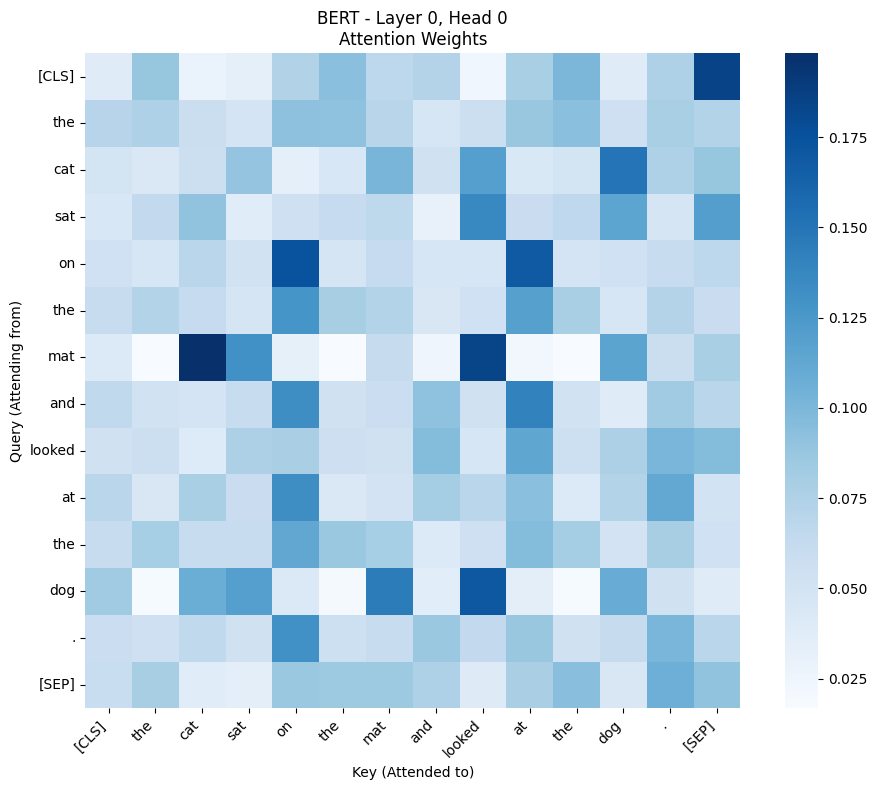

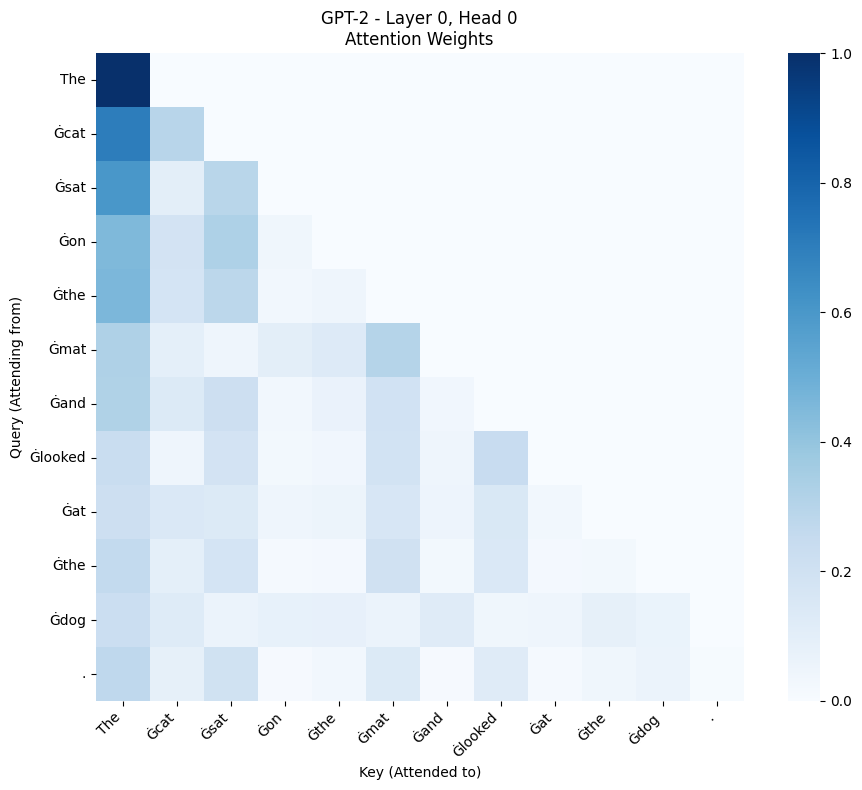

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_attention_heatmap(attention_weights, tokens, model_name, layer_idx=0, head_idx=0):
    """
    Создание heatmap для визуализации attention весов
    """
    if attention_weights is None:
        print(f"Невозможно создать heatmap для {model_name}: веса внимания не были получены.")
        return

    # TODO: Извлеките attention веса для указанного слоя и головы
    # attention_weights - это tuple тензоров (по одному на слой)
    # каждый тензор имеет форму (batch_size, num_heads, sequence_length, sequence_length)
    layer_attention = attention_weights[layer_idx] # (1, 12, seq_len, seq_len)

    # Извлекаем веса для конкретной головы
    # [:, head_idx, :, :] -> (1, seq_len, seq_len) -> (seq_len, seq_len)
    attention_matrix = layer_attention[0, head_idx, :, :].cpu().numpy()

    # ToDo: Создаем heatmap (уже реализовано через seaborn)
    # TODO: Создание heatmap используя seaborn
    # основная задача - визуализировать веса на каждый токен ( слово )
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True,
        square=True,
        # Добавим аннотации для лучшей читаемости (опционально, может быть перегружено)
        # annot=True, fmt='.2f'
    )

    plt.title(f'{model_name} - Layer {layer_idx}, Head {head_idx}\nAttention Weights')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45, ha="right") # ha="right" выравнивает метки по правому краю для лучшего вида при повороте
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Визуализируем attention для первого слоя и первой головы
# (Убедитесь, что bert_attention и gpt2_attention получены из предыдущего блока кода)

# Визуализируем attention для первого слоя и первой головы
plot_attention_heatmap(bert_attention, bert_tokens, 'BERT', layer_idx=0, head_idx=0)
plot_attention_heatmap(gpt2_attention, gpt2_tokens, 'GPT-2', layer_idx=0, head_idx=0)


### Задание 1.4: Анализ результатов

**TODO: Ответьте на следующие вопросы:**


1. **Какие различия вы заметили в attention patterns между BERT и GPT-2?**

   *Ваш ответ:*

2. **Как изменяются attention веса в разных слоях?**

   *Ваш ответ:*

3. **Какую роль играют позиционные кодировки?**

   *Ваш ответ:*


## 🚀 Часть 2: Дополнительные задания (30% оценки)

### Задание 2.1: Исследование Multi-Head Attention


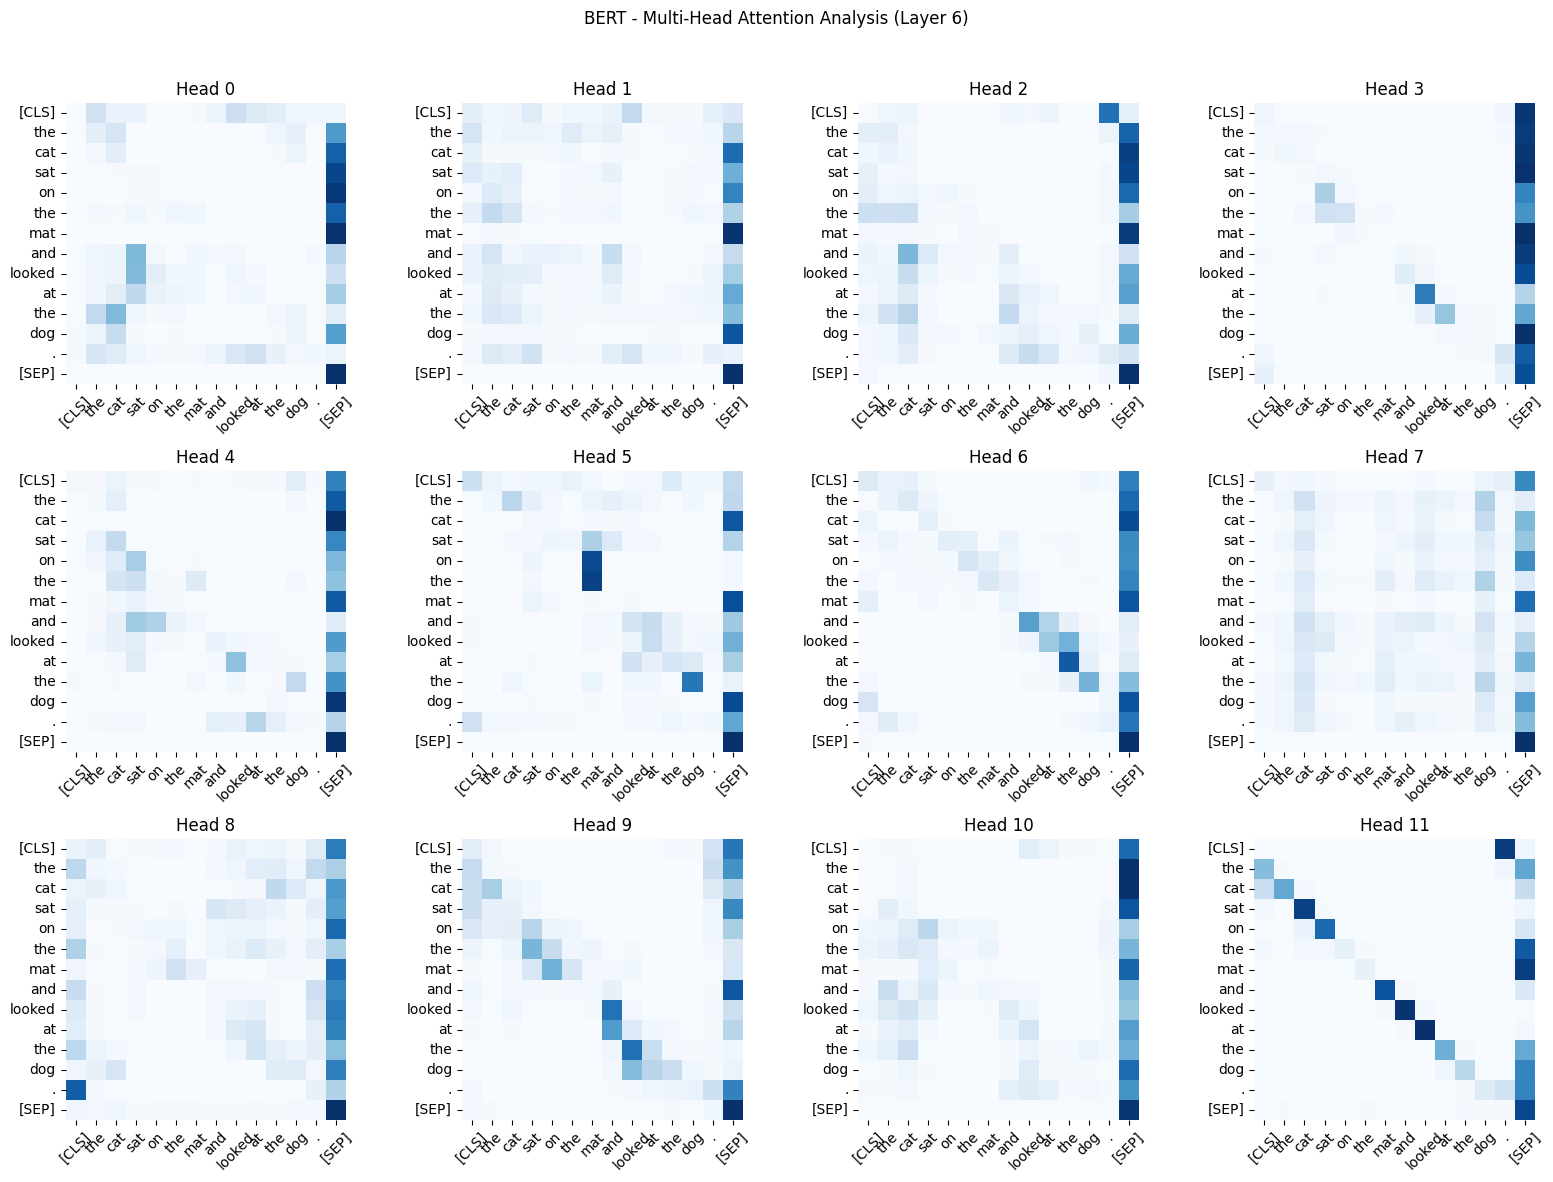

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_multi_head_attention(attention_weights, tokens, model_name, layer_idx=6):
    """
    Анализ того, как разные головы attention фокусируются на разных аспектах
    """
    if attention_weights is None:
        print(f"Невозможно проанализировать multi-head attention для {model_name}: веса внимания не были получены.")
 # num_heads можно получить из формы тензора для конкретного слоя
    # attention_weights[layer_idx] имеет форму (batch_size, num_heads, sequence_length, sequence_length)
    layer_attention = attention_weights[layer_idx] # (1, num_heads, seq_len, seq_len)
    num_heads = layer_attention.shape[1]

    # TODO: Создайте визуализацию attention для всех голов в одном слое
    # Используем subplots для отображения всех голов в одном окне
    # Предположим, мы хотим 4 колонки. Количество строк рассчитаем исходя из количества голов.
    cols = 4
    rows=(num_heads + cols - 1) // cols  # Округление вверх

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4)) # Увеличиваем размер пропорционально
    # axes может быть 1D array или scalar, если только одна ячейка
    if rows * cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes # Если одна строка
    else:
        axes = axes.flatten() # Превращаем в 1D array для удобства

    for head_idx in range(num_heads):
        ax = axes[head_idx]

        # Извлекаем веса для конкретной головы
        head_attention = layer_attention[0, head_idx, :, :].cpu().numpy() # (seq_len, seq_len)

        # Создаем heatmap для текущей головы
        sns.heatmap(
            head_attention,
            xticklabels=tokens,
            yticklabels=tokens,
            cmap='Blues',
            cbar=False, # Отключаем цветовую шкалу для каждой ячейки, чтобы не загромождать
            square=True,
            ax=ax # Указываем, на какой оси рисовать
        )

        ax.set_title(f'Head {head_idx}')
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    # Скрываем пустые субплоты, если голов не кратно cols
    for idx in range(num_heads, rows * cols):
        axes[idx].set_visible(False)

    plt.suptitle(f'{model_name} - Multi-Head Attention Analysis (Layer {layer_idx})')
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect оставляет место для suptitle
    plt.show()

# Анализируем multi-head attention для средних слоев
analyze_multi_head_attention(bert_attention, bert_tokens, 'BERT', layer_idx=6)


### Задание 2.2: Создание attention-карт для русскоязычного текста


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


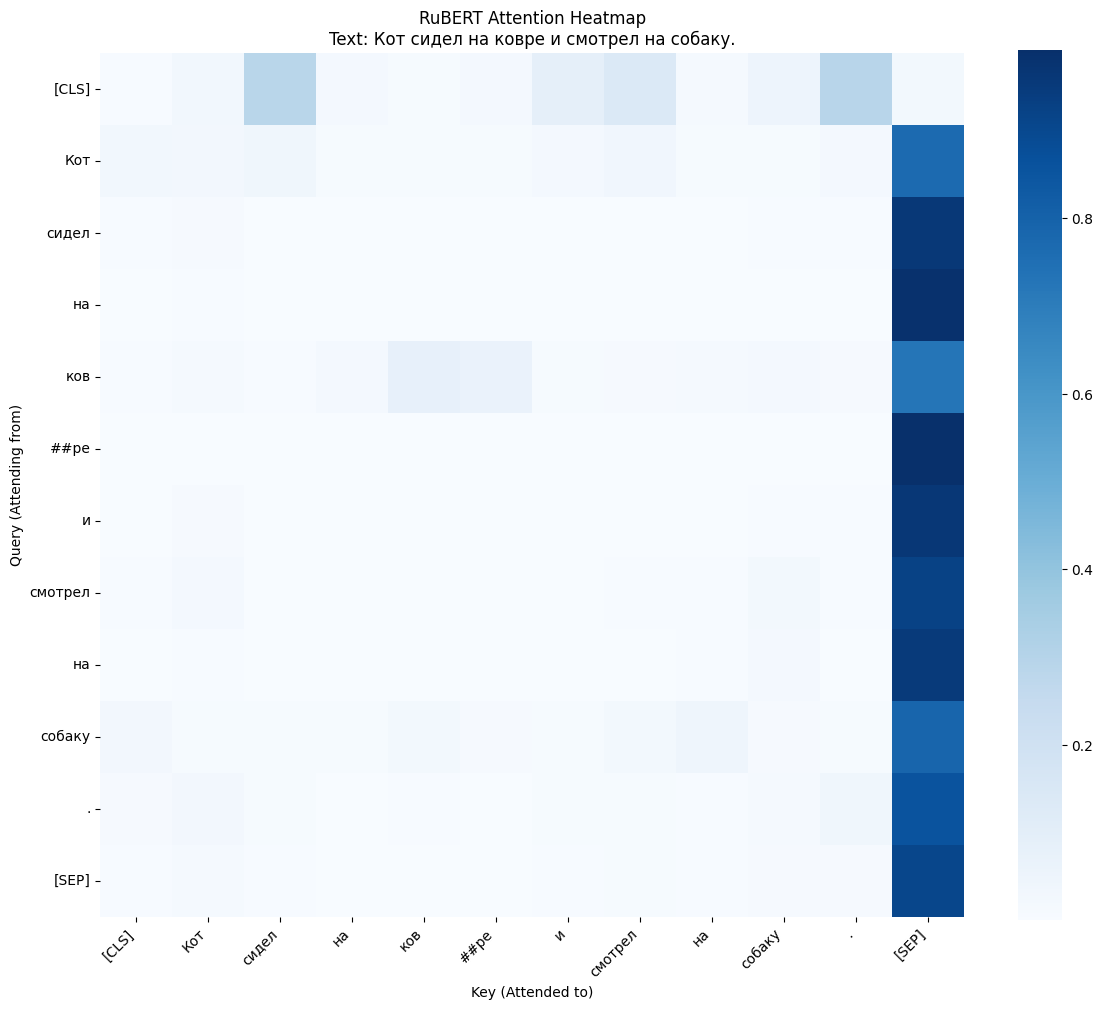


Токены: ['[CLS]', 'Кот', 'сидел', 'на', 'ков', '##ре', 'и', 'смотрел', 'на', 'собаку', '.', '[SEP]']
Количество слоев: 12
Количество голов: 12
Длина последовательности (в токенах): 12


In [20]:
# TODO: Загрузите русскоязычную модель и проанализируйте attention для русского текста
# ========= РЕШЕНИЕ: =========
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import torch # Требуется для .cpu().numpy()

# Загружаем русскоязычную модель
# Например, можно использовать DeepPavlov/rubert-base-cased
model_name = 'DeepPavlov/rubert-base-cased'

# Загружаем токенизатор и модель, настраивая их на возврат внимания
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name, output_attentions=True)
ru_tokenizer = AutoTokenizer.from_pretrained(model_name)
ru_model = AutoModel.from_pretrained(model_name, config=config)

# Русский текст для анализа
russian_text = "Кот сидел на ковре и смотрел на собаку."

def analyze_russian_attention(text, tokenizer, model):
    """
    Анализ attention для русского текста
    """
    # Устанавливаем модель в режим оценки
    model.eval()

    # Токенизация
    inputs = tokenizer(text, return_tensors="pt", add_special_tokens=True)

    # Получение выходов модели с включенным вниманием
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        attention_weights = outputs.attentions # tuple слоев

    # Получение токенов
    token_ids = inputs["input_ids"][0]
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Создаем heatmap для последнего слоя (обычно более семантически насыщенный)
    last_layer_idx = len(attention_weights) - 1
    # Извлекаем веса для последнего слоя, первой головы (или усредняем, если нужно)
    # Берем батч 0, голову 0
    attention_matrix = attention_weights[last_layer_idx][0, 0, :, :].cpu().numpy()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True,
        square=True,
        # Аннотации могут сделать график перегруженным, особенно для длинных предложений
        # annot=True,
        # fmt='.2f'
    )

    plt.title(f'RuBERT Attention Heatmap\nText: {text}')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return attention_weights, tokens

# Анализируем русский текст
ru_attention, ru_tokens = analyze_russian_attention(russian_text, ru_tokenizer, ru_model)

print(f"\nТокены: {ru_tokens}")
print(f"Количество слоев: {len(ru_attention)}")
if ru_attention:
    print(f"Количество голов: {ru_attention[0].shape[1]}")
    print(f"Длина последовательности (в токенах): {ru_attention[0].shape[2]}")



## 📈 Итоговый анализ и выводы

### Задание 3: Сравнительный анализ

**TODO: Сделайте итоговые выводы по результатам всех экспериментов:**


1. **Основные различия между BERT и GPT-2:**

   *Ваш анализ:*

2. **Как attention головы специализируются:**

   *Ваш анализ:*

3. **Особенности русскоязычных моделей:**

   *Ваш анализ:*

4. **Практические применения полученных знаний:**

   *Ваш анализ:*


## 🎯 Заключение

В этом задании вы:
- ✅ Изучили механизмы attention в трансформерах
- ✅ Сравнили разные архитектуры (BERT vs GPT-2)
- ✅ Проанализировали специализацию attention голов
- ✅ Работали с русскоязычными моделями

Полученные навыки визуализации и анализа attention будут полезны для:
- Отладки и оптимизации моделей
- Объяснения решений AI-систем
- Выбора подходящей архитектуры для задач
- Интерпретации поведения моделей

## 📋 Критерии сдачи ДЗ

### Обязательная часть (70% оценки):
- [x] Загружены и настроены модели BERT и GPT-2
- [x] Реализована функция получения attention весов
- [x] Создана базовая визуализация attention heatmap
- [x] Даны ответы на аналитические вопросы

### Дополнительная часть (30% оценки):
- [x] Проанализированы multi-head attention паттерны
- [x] Работа с русскоязычной моделью
- [x] Итоговый сравнительный анализ

**Удачи в дальнейшем изучении трансформеров! 🚀**
